## Boxplot

1. Чтение csv файла.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/ab-test.csv")

In [7]:
df[df["time"] == "before"].shape

(22, 4)

2. Формирование датафреймов.

In [8]:
df_after = df[df["time"] == "after"]
df_before = df[df["time"] == "before"]

before_control = df_before[df_before["group"] == "control"]
before_test = df_before[df_before["group"] == "test"]

after_control = df_after[df_after["group"] == "control"]
after_test = df_after[df_after["time"] == "after"]

data_after = [after_control["diff"], after_test["diff"]]
data_before = [before_control["diff"], before_test["diff"]]

3. Построение графиков.

C:\Users\X_X\AppData\Local\Temp\ipykernel_12820\1443562527.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(
C:\Users\X_X\AppData\Local\Temp\ipykernel_12820\1443562527.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(


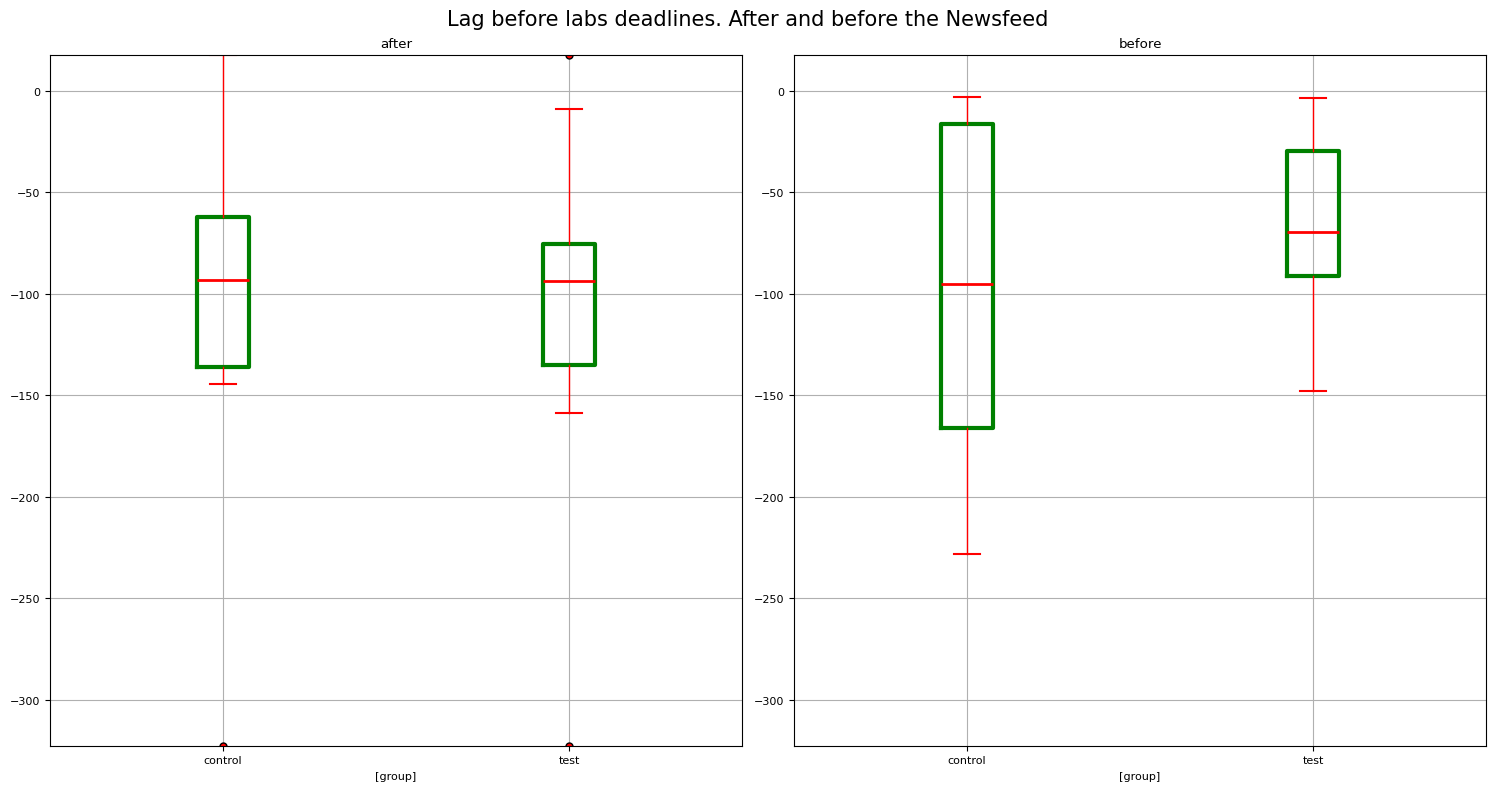

In [9]:
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["font.size"] = 8
fig, ax = plt.subplots(1, 2)


ax[0].boxplot(
    data_after, 
    labels=["control", "test"],
    patch_artist=False,
    boxprops=dict(linewidth=3, color='green'),
    medianprops=dict(linewidth=2, color='red'),
    whiskerprops=dict(linewidth=1, color='red'),
    capprops=dict(linewidth=1.5, color='red'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='red'))

ax[0].set_title("after")
ax[0].set_xlabel('[group]')
ax[0].grid()

ax[1].boxplot(
    data_before, 
    labels=["control", "test"],
    boxprops=dict(linewidth=3, color='green'),
    medianprops=dict(linewidth=2, color='red'),
    whiskerprops=dict(linewidth=1, color='red'),
    capprops=dict(linewidth=1.5, color='red'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='red'))

ax[1].set_title("before")
ax[1].set_xlabel('[group]')
ax[1].grid()

all_data = pd.concat([after_control["diff"], after_test["diff"], 
                     before_control["diff"], before_test["diff"]])

y_min = all_data.min()
y_max = all_data.max()

ax[0].set_ylim(y_min, y_max)
ax[1].set_ylim(y_min, y_max)

fig.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)
plt.tight_layout()
plt.show()

Вопросы:



In [10]:
before_control["diff"]
Q1 = before_control["diff"].quantile(0.25)
Q3 = before_control["diff"].quantile(0.75)

IQR = Q3 - Q1

IQL_rounded = round(IQR / 10) * 10

print(f"Каким был межквартильный размах в контрольной группе до публикации в ленте новостей?\nОтвет: {IQL_rounded}")

Каким был межквартильный размах в контрольной группе до публикации в ленте новостей?
Ответ: 150
